Columns found: ['Time (BJD-2457000)', ' Flux', ' Flattened Flux']


,Time (BJD-2457000),Flux,Flattened Flux
0,3235.348866,1.001028,0.999057
1,3235.349329,1.001114,0.999141
2,3235.349560,1.001423,0.999449
3,3235.349792,1.001788,0.999813
4,3235.350023,1.002057,1.000080


Using time column: 'Time (BJD-2457000)' (interpreted as BJD-2457000).
Using flux column: ' Flux'. Number of points: 191904
Created LightCurve; head:


time,flux,flux_err
,,
Time,float64,float64
3235.348865780709,1.00102768261368,nan
3235.3493287891606,1.00111385963957,nan
3235.349560293416,1.00142290191895,nan
3235.3497917976706,1.00178839504207,nan
3235.350023301867,1.00205655187267,nan


LS best period: 8.956060 d (frequency 0.11165623682850792 1 / d)


/home/ugnad/miniconda3/envs/.exo_25/lib/python3.12/site-packages/lightkurve/lightcurve.py:1129: LightkurveWarning: The light curve appears to be zero-centered (median=9.54e-05 +/- 4.41e-03); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


Sector/Quarter: Unknown
pgi: 0.012
A_avg: 0.400
B_avg: 0.442
Rsq_avg: 0.994
P_avg (days): 9.055
P_err (days): 0.074
HWHM_err (days): 1.415



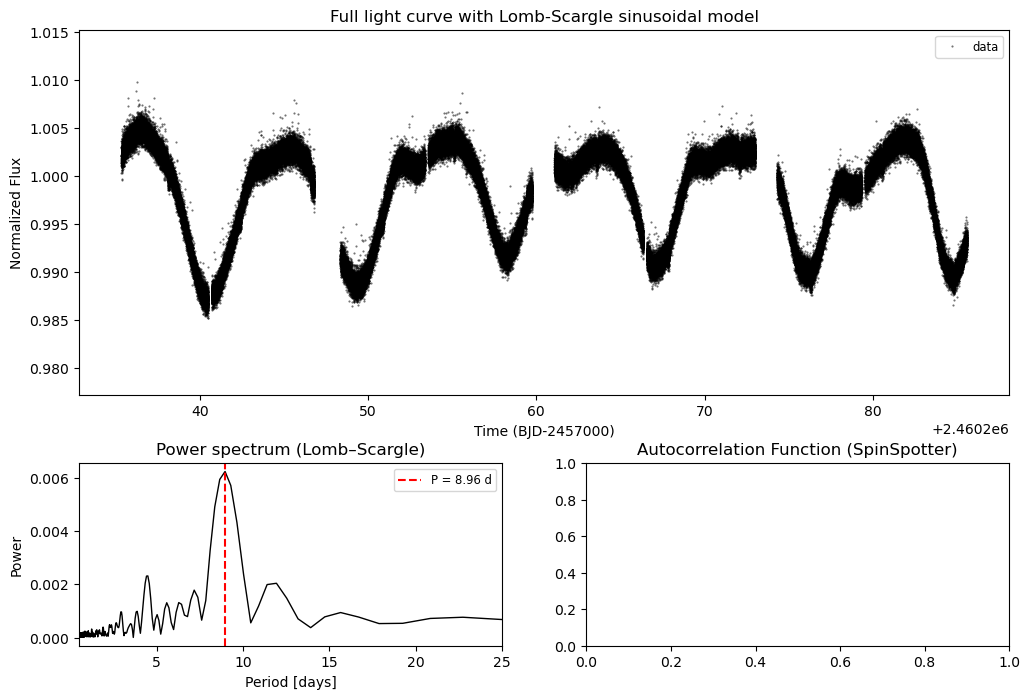

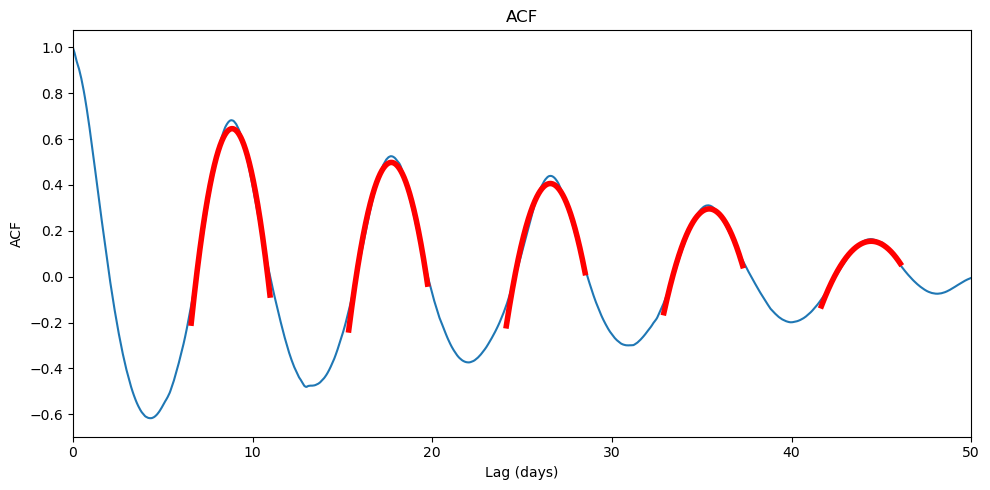

In [ ]:
# Combined figure: full LC + LS model (top), power spectrum (bottom-left), ACF (bottom-right)
# Requirements:
#   pip install lightkurve spinspotter statsmodels pyarrow     (install if needed)
# Note: you're already using SpinSpotter in your environment per earlier cells.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import astropy.units as u
from astropy.time import Time
import SpinSpotter as ss
from scipy import stats

# Matplotlib layout
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# === EDIT PATHS / PARAMETERS ===
# Choose one of your CSVs:
DATA_PATH = "./data/tic437011608flattened-20s.csv"
# DATA_PATH = "./data/tic437011608flattened-2min.csv"

# Lomb-Scargle search range (days)
min_period = 0.5
max_period = 25.0

# SpinSpotter box size (as you used earlier)
bs = 120

# =============================
# 1) Read CSV (your logic)
# =============================
df = pd.read_csv(DATA_PATH)
print('Columns found:', df.columns.tolist())
display(df.head())

# Detect time column (auto-detect based on 'time' or 'bjd')
time_col_candidates = [c for c in df.columns if 'time' in c.lower() or 'bjd' in c.lower()]
time_col = time_col_candidates[0] if time_col_candidates else df.columns[0]

# Force use of the 'Flux' column (2nd column) instead of Flattened Flux
if 'Flux' in df.columns:
    flux_col = 'Flux'
else:
    flux_col = df.columns[1]  # fallback to second column

# Parse arrays (your files use BJD-2457000)
time_rel = df[time_col].values.astype(float)
time_bjd = time_rel + 2457000.0
flux = df[flux_col].values.astype(float)

print(f"Using time column: '{time_col}' (interpreted as BJD-2457000).")
print(f"Using flux column: '{flux_col}'. Number of points: {len(time_rel)}")

# Build Lightkurve LightCurve (time in days)
lc = lk.LightCurve(time=time_rel, flux=flux)
print("Created LightCurve; head:")
display(lc.head())

# Keep numeric arrays
time = time_rel.copy()

# Optionally normalize / detrend a bit for LS (we'll zero-mean)
flux_for_ls = flux - np.nanmean(flux)
lc_for_ls = lk.LightCurve(time=time, flux=flux_for_ls)

# =============================
# 2) Lomb-Scargle via Lightkurve
# =============================
pg_ls = lc_for_ls.to_periodogram(method='lombscargle',
                                 minimum_period=min_period,
                                 maximum_period=max_period)

# Extract best period and frequency
P_best = pg_ls.period_at_max_power.to_value('day')
f_best = pg_ls.frequency_at_max_power
print(f"LS best period: {P_best:.6f} d (frequency {f_best})")

# Build model LightCurve (Lightkurve returns an object compatible with plotting)
# For LS, pg_ls.model(...) in many versions returns a LightCurve; use that.
try:
    lc_model = pg_ls.model(lc.time, frequency=f_best)
except Exception:
    # Fallback: call with numeric time array
    lc_model = pg_ls.model(lc.time.value, frequency=f_best)

# =============================
# 3) SpinSpotter ACF processing
# =============================
# Use the same lc (un-normalized or normalized as you prefer); SpinSpotter expects a LightCurve-like object
# We'll pass the Lightkurve lc (not lc_for_ls) so the printed times match your original.
fits_result, process_result = ss.process_LightCurve(lc, bs=bs)

# Optionally print summary (comment out if verbose)
ss.print_summary(fits_result, process_result, bs=bs)

# =============================
# 4) Build combined figure
# =============================
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], hspace=0.25, wspace=0.2)

# Top: full light curve with LS model (spans both columns)
ax_top = fig.add_subplot(gs[0, :])
# scatter raw data (use small alpha to show density)
ax_top.plot(time_bjd, flux, '.', color='k', markersize=1, alpha=0.6, label='data')
# overlay LS model
try:
    # lc_model is a LightCurve: use its time and flux for plotting
    ax_top.plot(lc_model.time + 2457000.0, lc_model.flux, '-', color='red', lw=2, label=f'LS model (P ~ {P_best:.6f} d)')
except Exception:
    # fallback: lc_model may be an array aligned with lc.time
    try:
        ax_top.plot(time_bjd, lc_model, '-', color='red', lw=2, label=f'LS model (P ~ {P_best:.6f} d)')
    except Exception:
        pass

ax_top.set_xlabel('Time (BJD-2457000)')
ax_top.set_ylabel('Normalized Flux')
ax_top.set_ylim(np.nanpercentile(flux, 0.5) - 0.01, np.nanpercentile(flux, 99.5) + 0.01)
ax_top.legend(loc='upper right', fontsize='small')
# ax_top.set_title('Full light curve with Lomb-Scargle sinusoidal model')

# Bottom-left: power spectrum (period on x-axis)
ax_bl = fig.add_subplot(gs[1, 0])
# get period & power arrays from periodogram (convert to plain arrays)
try:
    period_arr = pg_ls.period.to_value("day")
except Exception:
    # fallback if period is numpy array of Quantities
    period_arr = np.asarray(pg_ls.period)

power_arr = np.asarray(pg_ls.power)  # numeric array

# plot power vs period (user's image uses period on x-axis)
ax_bl.plot(period_arr, power_arr, '-', color='k', lw=1)
ax_bl.axvline(P_best, color='r', linestyle='--', label=f'P = {P_best:.2f} d')
ax_bl.set_xlabel('Period [days]')
ax_bl.set_ylabel('Power')
# ax_bl.set_title('Power spectrum (Lomb–Scargle)')
ax_bl.set_xlim(min_period, max(10, max_period))
ax_bl.legend(fontsize='small')

# Bottom-right: ACF – let SpinSpotter draw on this axes by making it current
ax_br = fig.add_subplot(gs[1, 1])
plt.sca(ax_br)
# SpinSpotter's plot_acf typically uses the current axes if available; pass the results
# If plot_acf creates its own figure, we attempt to plot into the chosen axes via plt.sca()
try:
    ss.plot_acf(fits_result, process_result, plot_peaks=True)
    # plot_acf likely plotted into ax_br because we set current axes, otherwise it will have created a new figure.
    # ax_br.set_title('Autocorrelation Function')
except Exception as e:
    # Fallback: compute and plot ACF ourselves if ss.plot_acf fails to draw into current axes
    print("ss.plot_acf failed to draw into current axes; falling back to manual ACF. Error:", e)
    # compute ACF from processed light curve (use statsmodels)
    from statsmodels.tsa.stattools import acf
    # SpinSpotter returns process_result with a 'lc' or similar; fall back to lc.flux
    acf_vals = acf(lc.flux.value - np.nanmean(lc.flux.value), nlags=200, fft=True, missing='conservative')
    lags = np.arange(len(acf_vals)) * np.median(np.diff(lc.time.value))
    ax_br.plot(lags, acf_vals, '-k')
    ax_br.set_xlabel('Lag [days]')
    ax_br.set_ylabel('ACF')
    ax_br.set_title('Autocorrelation (fallback)')

# Tight layout and show
plt.tight_layout()
plt.show()

Columns found: ['Time (BJD-2457000)', ' Flux', ' Flattened Flux']


,Time (BJD-2457000),Flux,Flattened Flux
0,3235.348866,1.001028,0.999057
1,3235.349329,1.001114,0.999141
2,3235.349560,1.001423,0.999449
3,3235.349792,1.001788,0.999813
4,3235.350023,1.002057,1.000080


Using time column: 'Time (BJD-2457000)' (interpreted as BJD-2457000).
Using flux column: ' Flux'. Number of points: 191904
LightCurve created:


time,flux,flux_err
,,
Time,float64,float64
3235.348865780709,1.00102768261368,nan
3235.3493287891606,1.00111385963957,nan
3235.349560293416,1.00142290191895,nan
3235.3497917976706,1.00178839504207,nan
3235.350023301867,1.00205655187267,nan


LS best period: 8.956060 d (frequency 0.11165623682850792 1 / d)


/home/ugnad/miniconda3/envs/.exo_25/lib/python3.12/site-packages/lightkurve/lightcurve.py:1129: LightkurveWarning: The light curve appears to be zero-centered (median=9.54e-05 +/- 4.41e-03); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


Sector/Quarter: Unknown
pgi: 0.012
A_avg: 0.400
B_avg: 0.442
Rsq_avg: 0.994
P_avg (days): 9.055
P_err (days): 0.074
HWHM_err (days): 1.415



/tmp/ipykernel_5258/2052735706.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


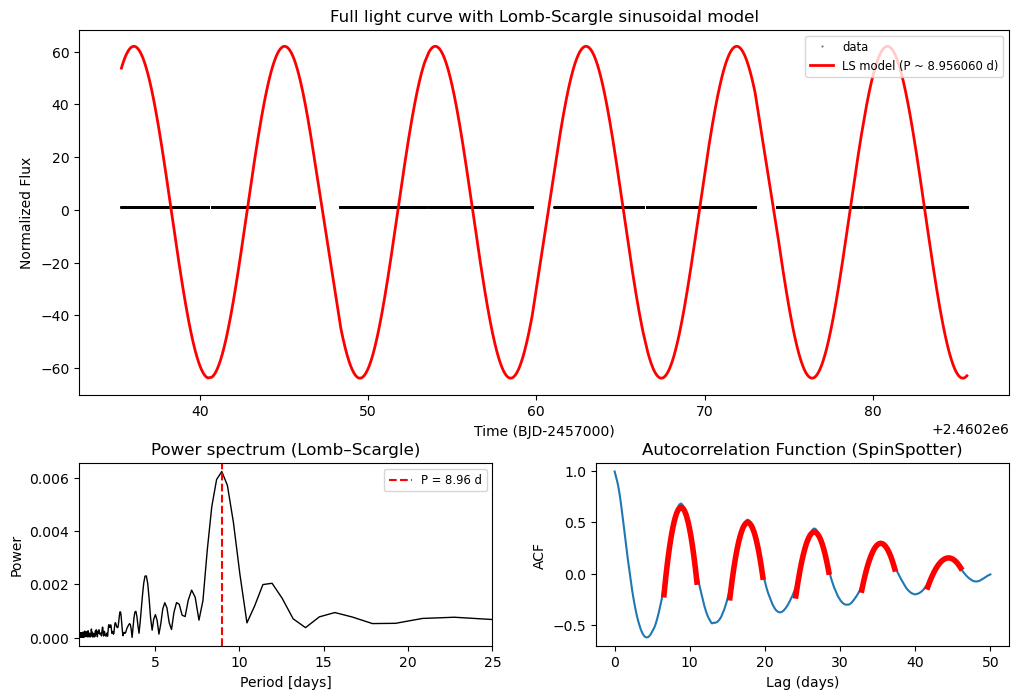

In [ ]:
# Combined figure: full LC + LS model (top), power spectrum (bottom-left), ACF (bottom-right)
# Requirements (already used in your environment): lightkurve, SpinSpotter, pandas, numpy, matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import astropy.units as u
from astropy.time import Time
import SpinSpotter as ss
from scipy import stats
import inspect

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# === EDIT PATHS / PARAMETERS ===
DATA_PATH = "./data/tic437011608flattened-20s.csv"
# DATA_PATH = "../data/tic437011608flattened-2min.csv"

# Lomb-Scargle search range (days)
min_period = 0.5
max_period = 25.0

# SpinSpotter box size (as you used earlier)
bs = 120

# =============================
# 1) Read CSV (your logic)
# =============================
df = pd.read_csv(DATA_PATH)
print('Columns found:', df.columns.tolist())
display(df.head())

# Detect time column (auto-detect based on 'time' or 'bjd')
time_col_candidates = [c for c in df.columns if 'time' in c.lower() or 'bjd' in c.lower()]
time_col = time_col_candidates[0] if time_col_candidates else df.columns[0]

# Force use of the 'Flux' column (2nd column) instead of Flattened Flux
if 'Flux' in df.columns:
    flux_col = 'Flux'
else:
    flux_col = df.columns[1]  # fallback to second column

# Parse arrays (your files use BJD-2457000)
time_rel = df[time_col].values.astype(float)   # relative days (BJD-2457000)
time_bjd = time_rel + 2457000.0
flux = df[flux_col].values.astype(float)

print(f"Using time column: '{time_col}' (interpreted as BJD-2457000).")
print(f"Using flux column: '{flux_col}'. Number of points: {len(time_rel)}")

# Create a Lightkurve LightCurve object (time in days)
lc = lk.LightCurve(time=time_rel, flux=flux)
print('LightCurve created:')
display(lc.head())

# Keep numeric arrays handy
time = time_rel.copy()

# Use a zero-mean version for LS fitting (like you did earlier)
flux_for_ls = flux - np.nanmean(flux)
lc_for_ls = lk.LightCurve(time=time, flux=flux_for_ls)

# =============================
# 2) Lomb-Scargle via Lightkurve
# =============================
pg_ls = lc_for_ls.to_periodogram(method='lombscargle',
                                 minimum_period=min_period,
                                 maximum_period=max_period)

# Extract best period and frequency
P_best = pg_ls.period_at_max_power.to_value('day')
f_best = pg_ls.frequency_at_max_power
print(f"LS best period: {P_best:.6f} d (frequency {f_best})")

# Build the LS model. Try to get a LightCurve back (many LK versions do that).
# If pg_ls.model returns a numpy array, coerce to a LightCurve for plotting/folding.
lc_model = None
try:
    # Try passing the lc.time object (works on many LK versions)
    model_candidate = pg_ls.model(lc.time, frequency=f_best)
    print("pg_ls.model returned type:", type(model_candidate))
except Exception:
    try:
        # Try numeric times if the signature wants those
        model_candidate = pg_ls.model(lc.time.value, frequency=f_best)
    except Exception as e:
        model_candidate = None
        print("pg_ls.model failed:", e)

# Coerce model_candidate into a LightCurve if needed
if model_candidate is None:
    lc_model = None
else:
    # If LightCurve already
    if isinstance(model_candidate, lk.LightCurve):
        lc_model = model_candidate
    else:
        # If model_candidate has 'time' and 'flux' attributes (table-like)
        if hasattr(model_candidate, 'time') and hasattr(model_candidate, 'flux'):
            try:
                lc_model = lk.LightCurve(time=model_candidate.time, flux=model_candidate.flux)
            except Exception:
                lc_model = None
        else:
            # If it's a plain flux array aligned to lc.time, build a LightCurve
            arr = np.asarray(model_candidate)
            if arr.shape == lc.time.value.shape:
                lc_model = lk.LightCurve(time=lc.time, flux=arr)
            else:
                # Last resort: try to interpret as tuple (time, flux)
                try:
                    tarr, farr = arr
                    lc_model = lk.LightCurve(time=tarr, flux=farr)
                except Exception:
                    lc_model = None

# =============================
# 3) SpinSpotter ACF processing
# =============================
# Use the original lc object for SpinSpotter (as you did previously).
fits_result, process_result = ss.process_LightCurve(lc, bs=bs)
# Optionally print summary
ss.print_summary(fits_result, process_result, bs=bs)

# =============================
# 4) Build combined figure
# =============================
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], hspace=0.25, wspace=0.25)

# Top: full light curve with LS model (spans both columns)
ax_top = fig.add_subplot(gs[0, :])

# Plot the raw data using the same small marker style you used earlier (preserve markersize)
ax_top.plot(time_bjd, flux, '.', color='k', markersize=1, alpha=0.6, label='data')

# Overlay the LS model using Lightkurve's plotting (preserves formatting)
if lc_model is not None:
    try:
        # lc_model.time may be relative (time_rel) or absolute; ensure we plot on same axis
        model_time = np.asarray(lc_model.time.value) if hasattr(lc_model.time, 'value') else np.asarray(lc_model.time)
        # If model_time matches lc.time (relative), convert to BJD-2457000 for plotting on same x-axis
        if np.allclose(model_time, lc.time.value, rtol=0, atol=1e-6):
            model_time_bjd = model_time + 2457000.0
        else:
            # If it's already absolute times (e.g., BJD), use as-is
            model_time_bjd = model_time
        # Plot the model flux on the top axes using the model time
        ax_top.plot(model_time_bjd, np.asarray(lc_model.flux), '-', color='red', lw=2, label=f'LS model (P ~ {P_best:.6f} d)')
    except Exception as e:
        # Final fallback: if lc_model couldn't be plotted directly, try plotting model_candidate array aligned with lc.time
        try:
            arr = np.asarray(model_candidate)
            if arr.shape == lc.time.value.shape:
                ax_top.plot(time_bjd, arr, '-', color='red', lw=2, label=f'LS model (P ~ {P_best:.6f} d)')
        except Exception:
            print("Failed to overlay model on top panel:", e)
else:
    print("Warning: lc_model is None; no LS model overlay will be plotted on top panel.")

ax_top.set_xlabel('Time (BJD-2457000)')
ax_top.set_ylabel('Normalized Flux')
ax_top.legend(loc='upper right', fontsize='small')
# ax_top.set_title('Full light curve with Lomb-Scargle sinusoidal model')

# Bottom-left: power spectrum (period on x-axis)
ax_bl = fig.add_subplot(gs[1, 0])
# get period & power arrays from periodogram (convert to plain arrays)
try:
    period_arr = pg_ls.period.to_value("day")
except Exception:
    period_arr = np.asarray(pg_ls.period)

power_arr = np.asarray(pg_ls.power)

ax_bl.plot(period_arr, power_arr, '-', color='k', lw=1)
ax_bl.axvline(P_best, color='r', linestyle='--', label=f'P = {P_best:.2f} d')
ax_bl.set_xlabel('Period [days]')
ax_bl.set_ylabel('Power')
# ax_bl.set_title('Power spectrum (Lomb–Scargle)')
ax_bl.set_xlim(min_period, max(10, max_period))
ax_bl.legend(fontsize='small')

# Bottom-right: ACF — try to get SpinSpotter to draw into this axes.
ax_br = fig.add_subplot(gs[1, 1])
# Strategy:
# 1) If ss.plot_acf accepts an ax or axes kwarg, use it.
# 2) Else call ss.plot_acf() (it may create its own figure); if it creates its own figure,
#    copy the artists (lines, markers) into our ax_br and then close the extra figure.

plot_acf_sig = inspect.signature(ss.plot_acf)
plot_acf_params = plot_acf_sig.parameters.keys()

if "ax" in plot_acf_params or "axes" in plot_acf_params:
    # call directly asking to draw into our axis (keeps SpinSpotter's native plotting)
    kwargs = {"plot_peaks": True}
    if "ax" in plot_acf_params:
        kwargs["ax"] = ax_br
    else:
        kwargs["axes"] = ax_br
    ss.plot_acf(fits_result, process_result, **kwargs)
    # ax_br.set_title('Autocorrelation Function (SpinSpotter)')
else:
    # Call ss.plot_acf but capture the figure it creates, then copy artists
    # Make sure current axes is ax_br for safety, but SpinSpotter may still create a new figure.
    plt.sca(ax_br)
    # call it (it may create a new figure)
    ss.plot_acf(fits_result, process_result, plot_peaks=True)
    # If SpinSpotter drew into a new figure (not our fig), copy artists.
    # The last created figure:
    fig2 = plt.gcf()
    # If fig2 is our main fig, ss.plot_acf drew into our axes already.
    if fig2 is not fig:
        # Attempt to find the ACF axes in fig2 (usually first axes)
        if len(fig2.axes) > 0:
            ax_src = fig2.axes[0]
            # Copy lines
            for line in ax_src.get_lines():
                x = line.get_xdata()
                y = line.get_ydata()
                ax_br.plot(x, y, linestyle=line.get_linestyle(), marker=line.get_marker(),
                           color=line.get_color(), lw=line.get_linewidth(), label=line.get_label())
            # Copy scatter collections if present
            for coll in ax_src.collections:
                offsets = coll.get_offsets()
                if offsets is not None and len(offsets) > 0:
                    ax_br.scatter(offsets[:,0], offsets[:,1],
                                  s=getattr(coll, "_sizes", [10])[0],
                                  c=coll.get_facecolor(), alpha=coll.get_alpha())
            # Copy x/y labels and title
            ax_br.set_xlabel(ax_src.get_xlabel())
            ax_br.set_ylabel(ax_src.get_ylabel())
            ax_br.set_title('Autocorrelation Function (SpinSpotter)')
        # Close the extra figure to avoid duplicate windows
        plt.close(fig2)

# Final touches
plt.tight_layout()
plt.show()


Columns found: ['Time (BJD-2457000)', ' Flux', ' Flattened Flux']


,Time (BJD-2457000),Flux,Flattened Flux
0,2500.195650,1.001089,1.000679
1,2500.197039,0.999310,0.998884
2,2500.198428,1.000477,1.000036
3,2500.199817,1.000212,0.999755
4,2500.201206,0.999567,0.999095


Using time column: 'Time (BJD-2457000)' (interpreted as BJD-2457000).
Using flux column: ' Flux'. Number of points: 32114
LightCurve created:


time,flux,flux_err
,,
Time,float64,float64
2500.1956496406824,1.00108931869761,nan
2500.197038669908,0.99930968700911,nan
2500.1984276991348,1.00047696316639,nan
2500.1998167283605,1.00021184008053,nan
2500.201205757616,0.99956660164543,nan


LS best period: 4.496023 d (frequency 0.2224188087484396 1 / d)
-- diagnostics --
Data: min, median, max = 0.99377533427757 0.999999938095095 1.00497088236343
Model (rescaled): min, median, max = -11.054241899902607 1.9998766184690162 11.157752312766808


/home/ugnad/miniconda3/envs/.exo_25/lib/python3.12/site-packages/lightkurve/lightcurve.py:1129: LightkurveWarning: The light curve appears to be zero-centered (median=1.45e-04 +/- 1.13e-03); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


Sector/Quarter: Unknown
pgi: 0.006
A_avg: 0.226
B_avg: 0.439
Rsq_avg: 0.997
P_avg (days): 4.809
P_err (days): 0.074
HWHM_err (days): 0.750



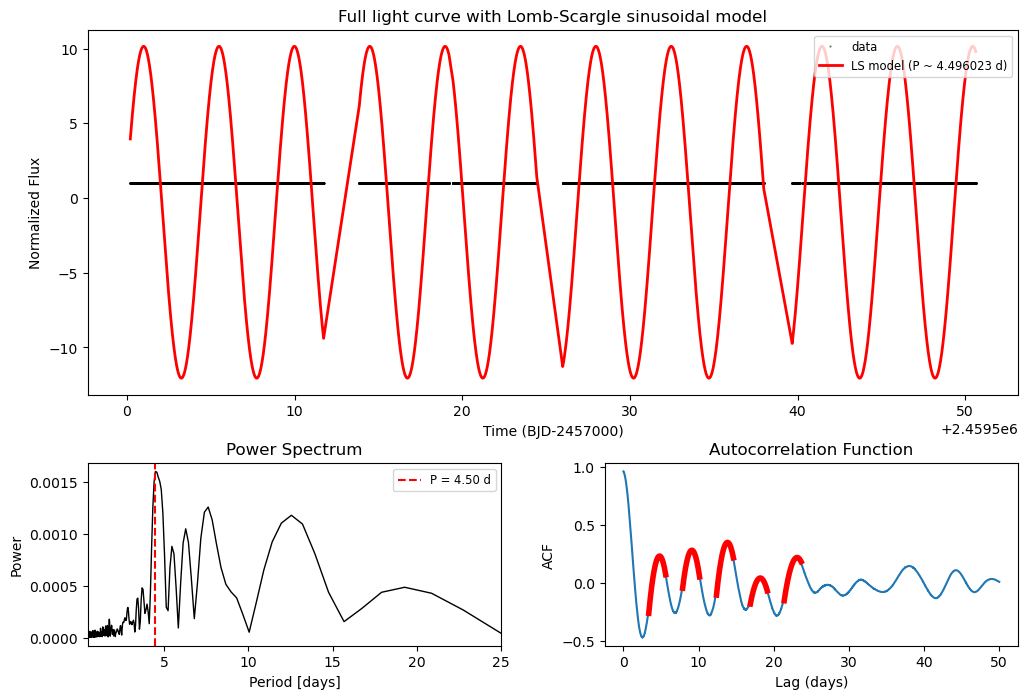

<Figure size 1200x800 with 0 Axes>

In [7]:
# Combined figure (fixed model scaling + embedded ACF)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import astropy.units as u
import SpinSpotter as ss
from scipy import stats
import matplotlib.gridspec as gridspec
import inspect

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# === EDIT PATHS / PARAMETERS ===
DATA_PATH = "./data/tic437011608flattened-20s.csv"
DATA_PATH = "./data/tic437011608flattened-2min.csv"

min_period = 0.5
max_period = 25.0
bs = 120  # SpinSpotter box size

# =============================
# 1) Read CSV (unchanged logic)
# =============================
df = pd.read_csv(DATA_PATH)
print('Columns found:', df.columns.tolist())
display(df.head())

time_col_candidates = [c for c in df.columns if 'time' in c.lower() or 'bjd' in c.lower()]
time_col = time_col_candidates[0] if time_col_candidates else df.columns[0]

if 'Flux' in df.columns:
    flux_col = 'Flux'
else:
    flux_col = df.columns[1]

time_rel = df[time_col].values.astype(float)   # relative days (BJD-2457000)
time_bjd = time_rel + 2457000.0
flux = df[flux_col].values.astype(float)

print(f"Using time column: '{time_col}' (interpreted as BJD-2457000).")
print(f"Using flux column: '{flux_col}'. Number of points: {len(time_rel)}")

lc = lk.LightCurve(time=time_rel, flux=flux)
print('LightCurve created:')
display(lc.head())

time = time_rel.copy()

# Create zero-mean LC for LS as before
flux_for_ls = flux - np.nanmean(flux)
lc_for_ls = lk.LightCurve(time=time, flux=flux_for_ls)

# =============================
# 2) Lomb-Scargle via Lightkurve
# =============================
pg_ls = lc_for_ls.to_periodogram(method='lombscargle',
                                 minimum_period=min_period,
                                 maximum_period=max_period)

P_best = pg_ls.period_at_max_power.to_value('day')
f_best = pg_ls.frequency_at_max_power
print(f"LS best period: {P_best:.6f} d (frequency {f_best})")

# Evaluate numeric model on the same times used for LS (use numeric times)
# Prefer to get a LightCurve from pg_ls.model(lc.time) when available, but make a numeric array version too
model_candidate = None
try:
    model_candidate = pg_ls.model(lc.time, frequency=f_best)   # prefer Lightkurve Time input
except Exception:
    try:
        model_candidate = pg_ls.model(lc.time.value, frequency=f_best)
    except Exception as e:
        print("pg_ls.model failed:", e)
        model_candidate = None

# Convert model_candidate to a numeric array aligned with lc.time.value
model_array = None
if model_candidate is None:
    model_array = None
else:
    # If a LightCurve was returned, take its flux
    if isinstance(model_candidate, lk.LightCurve):
        try:
            model_array = np.asarray(model_candidate.flux)
            model_time = np.asarray(model_candidate.time.value)
        except Exception:
            model_array = None
            model_time = None
    else:
        # If it's array-like, coerce to numpy array
        arr = np.asarray(model_candidate)
        # If arr is structured (e.g., table), try to pick flux column
        if arr.dtype.names is not None:
            # try 'flux' column
            if 'flux' in arr.dtype.names:
                model_array = np.asarray(arr['flux'])
                model_time = np.asarray(arr['time']) if 'time' in arr.dtype.names else np.asarray(lc.time.value)
            else:
                # fallback: take second field if exists (time, flux)
                try:
                    model_array = np.asarray(arr[1])
                    model_time = np.asarray(arr[0])
                except Exception:
                    model_array = None
                    model_time = None
        else:
            # plain numeric array
            if arr.shape == lc.time.value.shape:
                model_array = arr
                model_time = np.asarray(lc.time.value)
            else:
                # maybe tuple-like (time, flux)
                try:
                    tarr, farr = arr
                    model_time = np.asarray(tarr)
                    model_array = np.asarray(farr)
                except Exception:
                    model_array = None
                    model_time = None

# Now: model_array is the LS model evaluated on some time grid (preferably same length as lc.time)
# If model_array exists but on a different time grid, attempt to interpolate onto the lc.time grid
if model_array is not None and model_time is not None:
    if model_time.shape != lc.time.value.shape:
        # interpolate model onto lc.time.value
        try:
            from scipy.interpolate import interp1d
            interp_fn = interp1d(model_time, model_array, kind='linear', bounds_error=False, fill_value="extrapolate")
            model_on_lc_time = interp_fn(lc.time.value)
        except Exception:
            model_on_lc_time = None
    else:
        model_on_lc_time = model_array
else:
    model_on_lc_time = None

# IMPORTANT: pg_ls was computed on lc_for_ls (zero-mean flux). So model_on_lc_time is in the zero-mean scale.
# To overlay on the original flux (which is ~1.0 baseline), we add back the original mean flux:
if model_on_lc_time is not None:
    model_rescaled = model_on_lc_time + np.nanmean(flux)   # add the original flux mean
else:
    model_rescaled = None

# Debug prints to check scales (very helpful)
print("-- diagnostics --")
print("Data: min, median, max =", np.nanmin(flux), np.nanmedian(flux), np.nanmax(flux))
if model_rescaled is not None:
    print("Model (rescaled): min, median, max =", np.nanmin(model_rescaled), np.nanmedian(model_rescaled), np.nanmax(model_rescaled))
else:
    print("No model available to print diagnostics.")

# =============================
# 3) SpinSpotter ACF processing
# =============================
fits_result, process_result = ss.process_LightCurve(lc, bs=bs)
ss.print_summary(fits_result, process_result, bs=bs)

# =============================
# 4) Build combined figure (plot everything)
# =============================
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], hspace=0.25, wspace=0.25)

# Top panel: full LC with model overlay
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(time_bjd, flux, '.', color='k', markersize=1, alpha=0.6, label='data')

# Prefer to use lc_model.plot(ax=...) if pg_ls.model returned a LightCurve and we still have it
if isinstance(model_candidate, lk.LightCurve):
    try:
        # model_candidate may have relative times; convert to BJD if needed
        try:
            mtime = np.asarray(model_candidate.time.value)
            if np.allclose(mtime, lc.time.value, atol=1e-8):
                mtime_bjd = mtime + 2457000.0
            else:
                # assume already absolute or different grid, convert/interpolate handled below
                mtime_bjd = mtime
        except Exception:
            mtime_bjd = np.asarray(model_candidate.time)
        # Plot LightCurve model directly (works best with LK)
        ax_top.plot(mtime_bjd, np.asarray(model_candidate.flux), '-', color='red', lw=2, label=f'LS model (P ~ {P_best:.6f} d)')
    except Exception as e:
        # fallback: use numeric rescaled model if available
        if model_rescaled is not None:
            ax_top.plot(time_bjd, model_rescaled, '-', color='red', lw=2, label=f'LS model (P ~ {P_best:.6f} d)')
        else:
            print("Couldn't plot LightCurve model directly:", e)
else:
    # If we don't have a LightCurve, but we do have numeric rescaled model_on_lc_time -> plot that
    if model_rescaled is not None:
        ax_top.plot(time_bjd, model_rescaled, '-', color='red', lw=2, label=f'LS model (P ~ {P_best:.6f} d)')
    else:
        print("Warning: no LS model available to overlay on top panel.")

ax_top.set_xlabel('Time (BJD-2457000)')
ax_top.set_ylabel('Normalized Flux')
ax_top.legend(loc='upper right', fontsize='small')
ax_top.set_title('Full light curve with Lomb-Scargle sinusoidal model')

# Bottom-left: power spectrum (period on x-axis)
ax_bl = fig.add_subplot(gs[1, 0])
try:
    period_arr = pg_ls.period.to_value("day")
except Exception:
    period_arr = np.asarray(pg_ls.period)
power_arr = np.asarray(pg_ls.power)
ax_bl.plot(period_arr, power_arr, '-', color='k', lw=1)
ax_bl.axvline(P_best, color='r', linestyle='--', label=f'P = {P_best:.2f} d')
ax_bl.set_xlabel('Period [days]')
ax_bl.set_ylabel('Power')
ax_bl.set_title('Power Spectrum')
ax_bl.set_xlim(min_period, max(10, max_period))
ax_bl.legend(fontsize='small')

# Bottom-right: ACF via SpinSpotter: capture its figure and copy artists into our axes
ax_br = fig.add_subplot(gs[1, 1])

# Temporarily call plot_acf and capture its created fig
# Make a new figure so we can safely capture artists
fig_temp = plt.figure()
try:
    # This will create a figure with ACF; we will copy its artists to ax_br
    ss.plot_acf(fits_result, process_result, plot_peaks=True)
    fig_acf = plt.gcf()
    # find source axes (usually fig_acf.axes[0])
    if len(fig_acf.axes) > 0:
        ax_src = fig_acf.axes[0]
        # copy lines
        for line in ax_src.get_lines():
            ax_br.plot(line.get_xdata(), line.get_ydata(),
                       linestyle=line.get_linestyle(), marker=line.get_marker(),
                       color=line.get_color(), lw=line.get_linewidth(), label=line.get_label())
        # copy scatter collections (if any)
        for coll in ax_src.collections:
            offsets = coll.get_offsets()
            if offsets is not None and len(offsets) > 0:
                ax_br.scatter(offsets[:,0], offsets[:,1],
                              s=getattr(coll, "_sizes", [10])[0],
                              c=coll.get_facecolor(), alpha=coll.get_alpha(), label=coll.get_label())
        # copy labels and title
        ax_br.set_xlabel(ax_src.get_xlabel())
        ax_br.set_ylabel(ax_src.get_ylabel())
        ax_br.set_title('Autocorrelation Function')
    else:
        # fallback: manual ACF computation
        from statsmodels.tsa.stattools import acf
        acf_vals = acf(lc.flux.value - np.nanmean(lc.flux.value), nlags=200, fft=True, missing='conservative')
        lags = np.arange(len(acf_vals)) * np.median(np.diff(lc.time.value))
        ax_br.plot(lags, acf_vals, '-k')
        ax_br.set_xlabel('Lag [days]')
        ax_br.set_ylabel('ACF')
        ax_br.set_title('Autocorrelation (fallback)')
finally:
    # close the temporary figure to avoid duplicate windows
    plt.close(fig_acf)

# Final layout
plt.tight_layout()
plt.show()
